<h3 style="color:teal;text-align:center">⌞Model comparison plots⌟</h3>

Run this notebook after `training.ipynb`. It visualizes XGBoost, Random Forest, and LightGBM results.


In [7]:
from pathlib import Path
import json

import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

comparison_path = Path("models/model_comparison.json")
metadata_path = Path("models/best_model_metadata.json")

if comparison_path.exists():
    results = json.loads(comparison_path.read_text(encoding="utf-8"))
elif metadata_path.exists():
    metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
    results = metadata.get("all_results", {})
else:
    raise FileNotFoundError("Run training.ipynb first so models/model_comparison.json is created.")

comparison_df = pd.DataFrame(results).T[["MAE", "RMSE", "R2"]]
comparison_df = comparison_df.sort_values("R2", ascending=False)
comparison_df


,MAE,RMSE,R2
XGBoost,1.265530,2.352333,0.913056
Random Forest,2.559249,3.106962,0.848325
LightGBM,3.470040,4.407025,0.694837


<h4>• R2 comparison</h4>


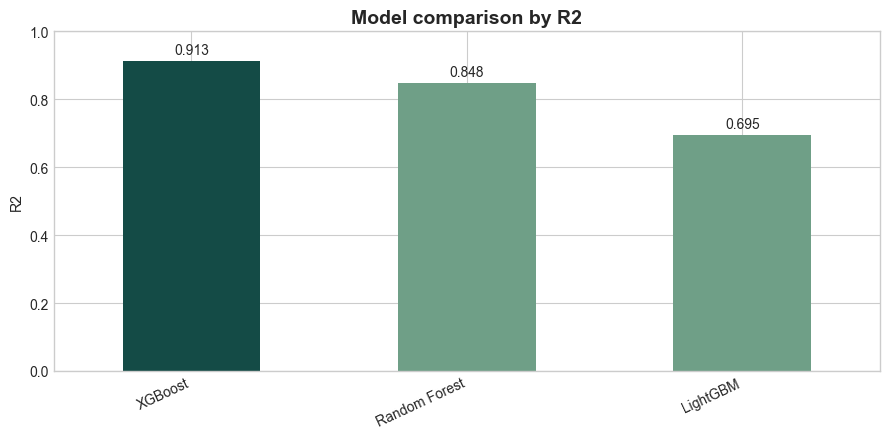

In [8]:
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ["#144b46" if i == 0 else "#6f9f87" for i in range(len(comparison_df))]
comparison_df["R2"].plot(kind="bar", ax=ax, color=colors)
ax.set_title("Model comparison by R2", fontsize=14, weight="bold")
ax.set_ylabel("R2")
ax.set_xlabel("")
ax.bar_label(ax.containers[0], fmt="%.3f", padding=3)
ax.set_ylim(0, max(1.0, comparison_df["R2"].max() + 0.05))
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


<h4>• Error comparison</h4>


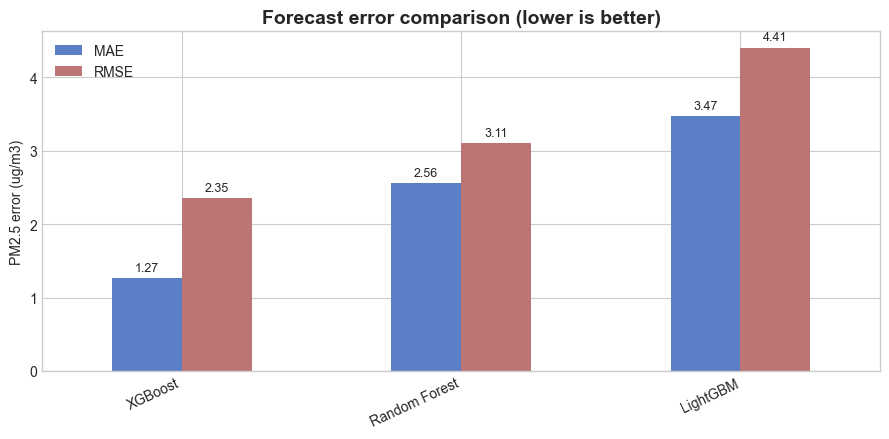

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.5))
comparison_df[["MAE", "RMSE"]].plot(kind="bar", ax=ax, color=["#5b7fc7", "#bd7474"])
ax.set_title("Forecast error comparison (lower is better)", fontsize=14, weight="bold")
ax.set_ylabel("PM2.5 error (ug/m3)")
ax.set_xlabel("")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3, fontsize=9)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


<h4>• Ranking table</h4>


In [10]:
ranking = comparison_df.copy()
ranking["Rank by R2"] = ranking["R2"].rank(ascending=False).astype(int)
ranking["Rank by RMSE"] = ranking["RMSE"].rank(ascending=True).astype(int)
ranking["Rank by MAE"] = ranking["MAE"].rank(ascending=True).astype(int)
ranking.sort_values("Rank by R2")


,MAE,RMSE,R2,Rank by R2,Rank by RMSE,Rank by MAE
XGBoost,1.265530,2.352333,0.913056,1,1,1
Random Forest,2.559249,3.106962,0.848325,2,2,2
LightGBM,3.470040,4.407025,0.694837,3,3,3


<h4>• Save figures</h4>


In [ ]:
output_dir = Path("figures")
output_dir.mkdir(exist_ok=True)

fig, ax = plt.subplots(figsize=(9, 4.5))
comparison_df["R2"].plot(kind="bar", ax=ax, color=["#144b46" if i == 0 else "#6f9f87" for i in range(len(comparison_df))])
ax.set_title("Model comparison by R2")
ax.set_ylabel("R2")
ax.set_xlabel("")
ax.bar_label(ax.containers[0], fmt="%.3f", padding=3)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
fig.savefig(output_dir / "model_r2_comparison.png", dpi=200)
plt.close(fig)

fig, ax = plt.subplots(figsize=(9, 4.5))
comparison_df[["MAE", "RMSE"]].plot(kind="bar", ax=ax, color=["#5b7fc7", "#bd7474"])
ax.set_title("Model error comparison")
ax.set_ylabel("PM2.5 error (ug/m3)")
ax.set_xlabel("")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3, fontsize=9)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
fig.savefig(output_dir / "model_error_comparison.png", dpi=200)
plt.close(fig)

print(f"Saved figures to {output_dir.resolve()}")


Saved figures to C:\Users\abdoi\OneDrive\Documents\Studies\master ai\S2\ML\project\report_figures
